In [18]:
import numpy as np
import matplotlib.pyplot as plt

from src.grid import Grid
from src.elementary_solutions import SourceSink, UniformFlow
from src.superposition import Superposition

In [19]:
naca0012_x = np.loadtxt('../resources/NACA0012_x.txt')
naca0012_y = np.loadtxt('../resources/NACA0012_y.txt')
naca0012_sigma = np.loadtxt('../resources/NACA0012_sigma.txt')

In [20]:
u_inf = 1.0

In [32]:
nx, ny = 50, 50                                # number of points in each direction
x_start, x_end = -1.0, 2.0            # boundaries in the x-direction
y_start, y_end = -0.5, 0.5            # boundaries in the y-direction

grid = Grid(x_start=x_start, x_end=x_end, y_start=y_start, y_end=y_end, nx=nx, ny=ny)

In [33]:
sources = []
for x, y, sigma in zip(naca0012_x, naca0012_y, naca0012_sigma):

    sources.append(SourceSink(strength=sigma, x=x, y=y))


In [34]:

uniform_flow = UniformFlow(U_inf=u_inf)


In [35]:

elementary_solutions = sources + [uniform_flow]

In [36]:
naca0012_flow = Superposition(elementary_solutions=elementary_solutions)

u, v = naca0012_flow.velocity_field(grid)

psi = naca0012_flow.stream_function(grid)

cp = naca0012_flow.pressure_coefficient(grid, u_inf=u_inf)

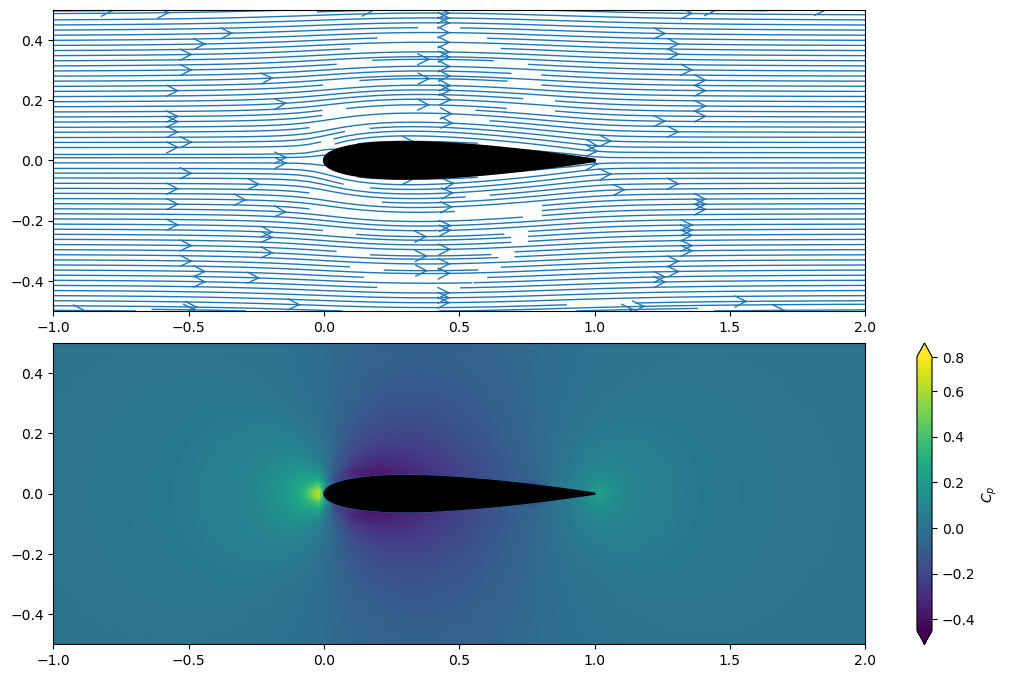

In [44]:

width = 10.0
height = (y_end - y_start) / (x_end - x_start) * width * 2.0

fig, ax = plt.subplots(2, 1, figsize=(width, height), constrained_layout=True)

ax[0].streamplot(grid.X, grid.Y, u, v,
                density=2, linewidth=1, arrowsize=2, arrowstyle='->')
ax[0].plot(naca0012_x, naca0012_y)
ax[0].fill(naca0012_x,
            naca0012_y,
            color='k', linestyle='solid', linewidth=2, zorder=2)
ax[0].set_xlim(x_start, x_end)
ax[0].set_ylim(y_start, y_end)

ctrf = ax[1].contourf(grid.X, grid.Y, cp,
                      levels=np.linspace(-0.45, 0.75, 200), extend='both')
cbar = fig.colorbar(ctrf, label='$C_p$')
cbar.set_ticks([-0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8])
ax[1].plot(naca0012_x, naca0012_y)
ax[1].fill(naca0012_x, naca0012_y, color='k', zorder=2)
ax[1].set_xlim(x_start, x_end)
ax[1].set_ylim(y_start, y_end)
plt.show()